# Task 6: Customer Segmentation

## Objective
Group customers based on their behavior using K-Means Clustering.

### Tasks Performed
- Data Preprocessing
- K-Means Clustering
- Cluster Visualization
- Customer Segment Insights

**Dataset:** Mall Customer Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Libraries Imported Successfully")


Libraries Imported Successfully


## Load Dataset

In [2]:
# Load Dataset
# Change file name if needed

df = pd.read_csv('Mall_Customers.csv')

df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Basic Information and Data Exploration

In [3]:
print("Shape of Dataset:", df.shape)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
display(df.describe())


Shape of Dataset: (200, 5)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistical Summary


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Data Preprocessing

For customer segmentation, we will use:

- Annual Income (k$)
- Spending Score (1-100)


In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
# feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Data Preprocessed Successfully")


Data Preprocessed Successfully


## Finding Optimal Number of Clusters (Elbow Method)

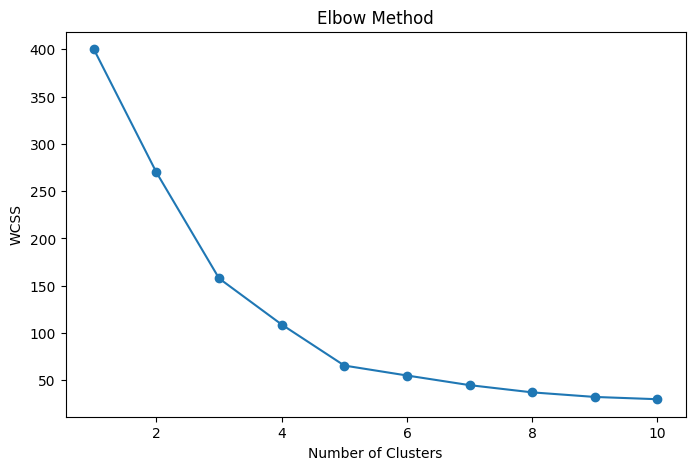

In [6]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


## Apply K-Means Clustering

Based on the elbow graph, we choose **5 clusters**.


In [7]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Visualize Customer Segments

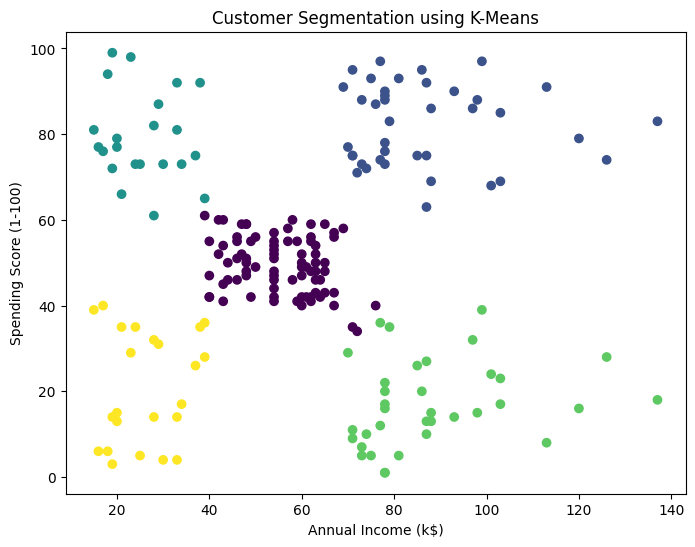

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation using K-Means')

plt.show()


## Number of Customers in Each Segment

In [9]:
segment_count = df['Cluster'].value_counts().sort_index()

print(segment_count)


Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


## Customer Segment Insights

Typical interpretation:

### Cluster 0
High income and high spending customers.
These are premium customers and should be targeted with exclusive offers.

### Cluster 1
Low income and low spending customers.
These customers are budget-conscious.

### Cluster 2
High income but low spending customers.
Potential customers for marketing campaigns.

### Cluster 3
Low income but high spending customers.
Can be targeted with loyalty programs.

### Cluster 4
Average income and average spending customers.
Regular customers with stable purchasing behavior.


# Conclusion

K-Means clustering successfully grouped customers into different segments based on Annual Income and Spending Score.

These customer groups can help businesses:
- Improve marketing strategies
- Increase customer retention
- Provide personalized offers
- Understand customer behavior better
